# Análisis exploratorio de incidencia delictiva en México

In [252]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [253]:
df = pd.read_csv('data/delitos.csv')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

In [254]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153600 entries, 0 to 153599
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   anio            153600 non-null  int64  
 1   clave_ent       153600 non-null  int64  
 2   entidad         153600 non-null  str    
 3   tipo_de_delito  153600 non-null  str    
 4   nombre_mes      153600 non-null  str    
 5   fecha           153600 non-null  str    
 6   frecuencia      153600 non-null  float64
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 MB


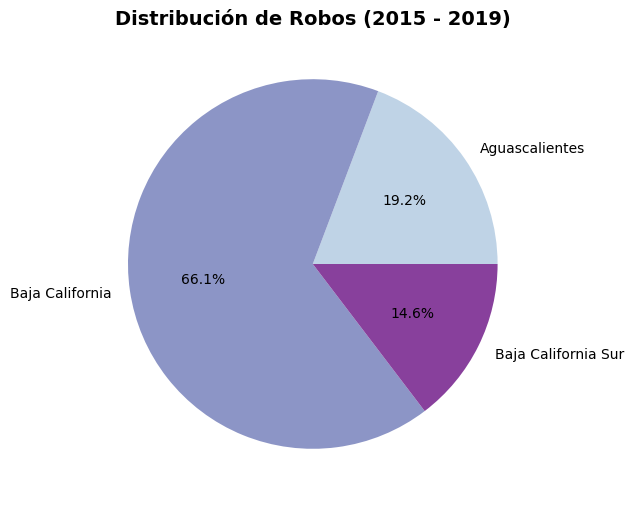

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns

EntidadesMx = ["Aguascalientes", "Baja California", "Baja California Sur"]

filtrado = df[
    (df["entidad"].isin(EntidadesMx)) &
    (df["tipo_de_delito"] == "Robo") &
    (df["anio"] >= 2015 ) &
    (df["anio"] <= 2019)
]

#1. Sumamos el total global de robos por cada estado
datos_simples = filtrado.groupby("entidad")["frecuencia"].sum()

# 2. Dibujamos el pastel usando una paleta azul/morada directa de Seaborn
plt.figure(figsize=(6, 6))
plt.pie(
    datos_simples, 
    labels=datos_simples.index, 
    autopct='%1.1f%%',
    colors=sns.color_palette("BuPu", len(datos_simples)) # Genera los colores azul-morado en una línea
)

plt.title("Distribución de Robos (2015 - 2019)", fontsize=14, fontweight="bold")
plt.show()





In [256]:
# Notas 

df[
    (df["entidad"] == "México")
]

,anio,clave_ent,entidad,tipo_de_delito,nombre_mes,fecha,frecuencia
6720,2015,15,México,Aborto,abril,2015-04-01,5.0
6721,2015,15,México,Aborto,agosto,2015-08-01,5.0
6722,2015,15,México,Aborto,diciembre,2015-12-01,4.0
6723,2015,15,México,Aborto,enero,2015-01-01,10.0
6724,2015,15,México,Aborto,febrero,2015-02-01,9.0
...,...,...,...,...,...,...,...
145435,2024,15,México,Violencia familiar,marzo,2024-03-01,2493.0
145436,2024,15,México,Violencia familiar,mayo,2024-05-01,2691.0
145437,2024,15,México,Violencia familiar,noviembre,2024-11-01,0.0
145438,2024,15,México,Violencia familiar,octubre,2024-10-01,0.0


In [257]:
a =print(df["clave_ent"].unique())
b = print(df["entidad"].unique())
c = print(df["tipo_de_delito"].unique())
d = print(df["nombre_mes"].unique())


[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32]
<StringArray>
[                 'Aguascalientes',                 'Baja California',
             'Baja California Sur',                        'Campeche',
            'Coahuila de Zaragoza',                          'Colima',
                         'Chiapas',                       'Chihuahua',
                'Ciudad de México',                         'Durango',
                      'Guanajuato',                        'Guerrero',
                         'Hidalgo',                         'Jalisco',
                          'México',             'Michoacán de Ocampo',
                         'Morelos',                         'Nayarit',
                      'Nuevo León',                          'Oaxaca',
                          'Puebla',                       'Querétaro',
                    'Quintana Roo',                 'San Luis Potosí',
                         'Sinaloa',

In [258]:
OrdenMeses = 'enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre'



#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [259]:
#Pregunta 1

HomicidiosCol = df[(df['entidad'] == 'Colima') & (df['anio'] == 2018) & (df['tipo_de_delito'] == "Homicidio")]



TotalCol = HomicidiosCol["frecuencia"].sum()

print(f"Homicidios dolosos en colima en 2018: {TotalCol}")

Homicidios dolosos en colima en 2018: 726.0


In [260]:
#Pregunta 2

RoboAutos = df[
    (df['tipo_de_delito'] == 'Robo') & 
    (df['anio'] == 2019)
    ]

TotalRoboAutos = RoboAutos['frecuencia'].sum()
print(f'Robos de autos en todo el año 2019: {TotalRoboAutos} Eobos de Auto')

'''
NOTA: Sé que dice que tenemos que trabajar con los robos de autos y no robos generales, pero miren
En el archivo csv resultante de las consulas del archivo "1_limpieza_de_datos.ipynb" quitraron los sub tipos de delito...
Entonces... Bajo la inficaci[on del hub, voy a trabajar con este archivo

Cualquier aclaracion, por favor, mandenme mensaje por el chat
Gracias]
''' 


Robos de autos en todo el año 2019: 766096.0 Eobos de Auto


'\nNOTA: Sé que dice que tenemos que trabajar con los robos de autos y no robos generales, pero miren\nEn el archivo csv resultante de las consulas del archivo "1_limpieza_de_datos.ipynb" quitraron los sub tipos de delito...\nEntonces... Bajo la inficaci[on del hub, voy a trabajar con este archivo\n\nCualquier aclaracion, por favor, mandenme mensaje por el chat\nGracias]\n'

In [261]:
# prueba = df[(df["tipo_de_delito"] == "Feminicidio") & (df["frecuencia"] >= 17)]

In [262]:
#Pregunta 3

Filtrodelito = ["Homicidio", "Feminicidio"]
FiltroGlobal = df[
    (df["tipo_de_delito"].isin(Filtrodelito))
]

FiltroGlobal.groupby("anio")['frecuencia'].sum().reset_index()


,anio,frecuencia
0,2015,31744.0
1,2016,36018.0
2,2017,42068.0
3,2018,45385.0
4,2019,45822.0
5,2020,44223.0
6,2021,44960.0
7,2022,43845.0
8,2023,42846.0
9,2024,22307.0


In [263]:
#Pregunta 4
MaxFem = df[(df["tipo_de_delito"] == "Feminicidio") & (df["frecuencia"] >= 19)]

MaxFem.reset_index()

,index,anio,clave_ent,entidad,tipo_de_delito,nombre_mes,fecha,frecuencia
0,83717,2020,15,México,Feminicidio,julio,2020-07-01,19.0
1,99073,2021,15,México,Feminicidio,agosto,2021-08-01,19.0
2,114442,2022,15,México,Feminicidio,octubre,2022-10-01,19.0


In [264]:
#Pregunta 5 ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

femenicidio = df[(df["tipo_de_delito"] == "Feminicidio")]

AgruparFem = femenicidio.groupby(["anio","entidad"])["frecuencia"].sum().reset_index()
resultado = AgruparFem[(AgruparFem["frecuencia"]) == (AgruparFem["frecuencia"].max())]

resultado.reset_index()




,index,anio,entidad,frecuencia
0,176,2020,México,151.0


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

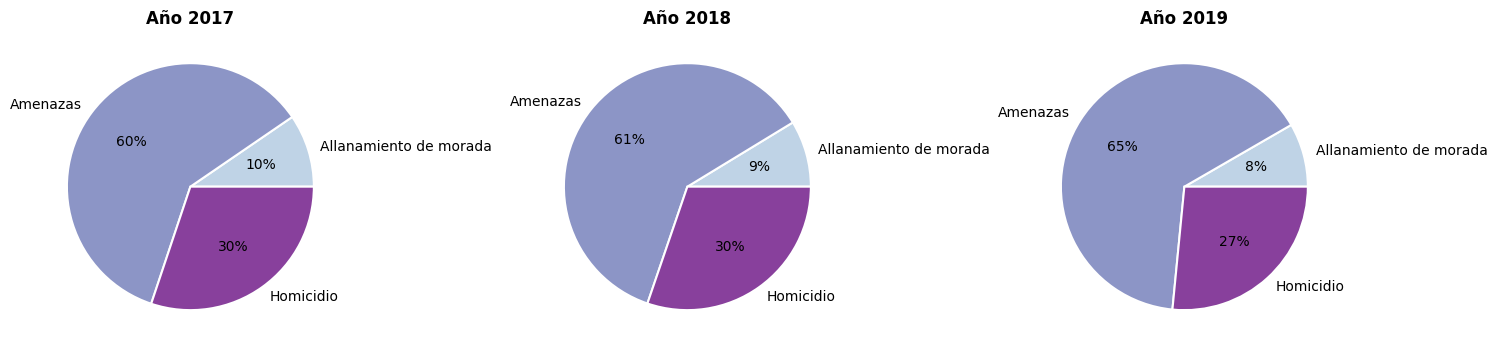

In [284]:
import matplotlib.pyplot as plt
import seaborn as sns

FiltroInicial = ['Allanamiento de morada', 'Amenazas','Homicidio']

FiltroDelito1 = df[
    (df["tipo_de_delito"].isin(FiltroInicial))
]

FiltroGlobal2 = FiltroDelito1[
    (FiltroDelito1).isin(FiltroDelito1)
]

AgruparFiltro = FiltroGlobal2.groupby(['anio','tipo_de_delito'])['frecuencia'].sum().reset_index()

AgruparFiltro

# Creamos la fila con 3 espacios para los años 2017, 2018 y 2019
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# --- PASTEL 1: AÑO 2017 (Cajón 0) ---
datos_2017 = AgruparFiltro[AgruparFiltro["anio"] == 2017]
axes[0].pie(
    datos_2017["frecuencia"], 
    labels=datos_2017["tipo_de_delito"], 
    autopct='%1.0f%%',
    colors=sns.color_palette("BuPu", len(datos_2017)), # Degradado azul-morado automático
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title("Año 2017", fontweight="bold")

# --- PASTEL 2: AÑO 2018 (Cajón 1) ---
datos_2018 = AgruparFiltro[AgruparFiltro["anio"] == 2018]
axes[1].pie(
    datos_2018["frecuencia"], 
    labels=datos_2018["tipo_de_delito"], 
    autopct='%1.0f%%',
    colors=sns.color_palette("BuPu", len(datos_2018)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title("Año 2018", fontweight="bold")

# --- PASTEL 3: AÑO 2019 (Cajón 2) ---
datos_2019 = AgruparFiltro[AgruparFiltro["anio"] == 2019]
axes[2].pie(
    datos_2019["frecuencia"], 
    labels=datos_2019["tipo_de_delito"], 
    autopct='%1.0f%%',
    colors=sns.color_palette("BuPu", len(datos_2019)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[2].set_title("Año 2019", fontweight="bold")

# Ajustamos márgenes y renderizamos
plt.tight_layout()
plt.show()


---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [266]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0
